# Multi-task CNN-TCN — Pacific input -> ENSO + South Asia impact (Approach 3)

**Design (forward-teleconnection, matches the proposal's data flow):**
- **Input:** 12-month windows of the **tropical Pacific** grid with six pre-standardised
  (`_z`) anomaly channels — `sst`, `msl`, zonal (`iews`) & meridional (`inss`) wind stress,
  upper-300 m ocean heat content (`sohtc300`), and 20 C-isotherm depth (`so20chgt`).
- **Shared encoder:** one CNN-TCN turns the Pacific window into an encoded vector `z`.
- **Two heads (multi-task):** an **ENSO head** (monthly Nino 3.4 ONI scalar) and an
  **impact head** (single-month `t2m` & `tp` anomalies over the South Asia grid, flattened).
- **Loss:** `L_total = alpha * L_ENSO + (1 - alpha) * L_impact`, with the impact term being
  `MSE + LAMBDA_CORR * (1 - spatial_r)` so pattern (not just magnitude) is rewarded.
- **Rolling monthly targets:** every calendar month is a sample (~500+), not just JJAS.
- **No leakage:** the Pacific input window ends `LEAD` months *before* the target month;
  train-only standardisation stats are used for the input.

> This is the forward-teleconnection counterpart to `CNN_TCN_impact.ipynb` (which used South
> Asian fields as input). Here the Pacific *drives* both the ENSO index and the SA impacts.
> Run from the `data_analysis/` folder (or the Colab Drive equivalent) so `data/...` resolves.


In [1]:
# # --- Environment bootstrap (Colab or local GPU) ---
# import os
# try:
#     from google.colab import drive          # only importable inside Colab
#     drive.mount('/content/drive')
#     BASE_DIR = '/content/drive/MyDrive/ElNino'   # <-- match your Drive folder
# except ImportError:
#     # Local run: pick whichever dir actually holds data/ (this notebook's dir, or repo root -> data_analysis).
#     BASE_DIR = '.' if os.path.exists('data/Combined/combined_era5_oras5.csv') else 'data_analysis'
# os.chdir(BASE_DIR)
# print('Working dir:', os.getcwd())
# print('Pacific present:', os.path.exists('data/Combined/combined_era5_oras5.csv'))
# print('SA present     :', os.path.exists('data/era5_southasia_with_precip_1980_2025.csv'))
# print('ONI present    :', os.path.exists('data/Combined/nino34_index_3month_running_mean_official_oni.csv'))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

# --- Config ---
PAC_VARS    = ['sst_anom_z', 'msl_anom_z', 'avg_iews_anom_z', 'avg_inss_anom_z',
               'sohtc300_anom_z', 'so20chgt_anom_z']   # Pacific input channels
IMPACT_VARS = ['t2m_anom_z', 'tp_anom_z']              # South Asia target fields
SEQ_LEN     = 12            # months per input window
LEAD        = 3             # forecast issued this many months before the target month
TARGET_COL  = 'nino34_3m'   # 3-month running-mean Nino 3.4 = official ONI

PAC_CSV  = 'data/Combined/combined_era5_oras5.csv'
SA_CSV   = 'data/era5_southasia_with_precip_1980_2025.csv'
NINO_CSV = 'data/Combined/nino34_index_3month_running_mean_official_oni.csv'

BATCH_SIZE   = 8
EPOCHS       = 400
LR           = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.3          # regularization on shared encoder + both heads
ALPHA        = 0.5          # weight on the ENSO loss in L_total (0.5 balances ENSO vs the PCA-eased impact task best)
LAMBDA_CORR  = 0.5          # weight on the (1 - spatial-r) term inside L_impact
PATIENCE     = 60
CKPT_PATH    = 'cnn_tcn_multitask_pacific_best.pt'
N_PCA_COMPONENTS = 15        # dominant SA impact modes the impact head decodes into


PyTorch 2.6.0+cu124 | device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 1 · Build the Pacific input tensor `(T, H, W, C)`

Reindex onto a complete `(time x lat x lon)` grid so ordering is guaranteed, then fill any
missing cell with `0.0` (neutral anomaly). This is the **input** the encoder sees.


In [3]:
pac_df = pd.read_csv(PAC_CSV)
pac_df['time'] = pd.to_datetime(pac_df['time'])
pac_times = np.sort(pac_df['time'].unique())
pac_lats  = np.sort(pac_df['latitude'].unique())
pac_lons  = np.sort(pac_df['longitude'].unique())
Tp, Hp, Wp, Cp = len(pac_times), len(pac_lats), len(pac_lons), len(PAC_VARS)
print(f'Pacific: T={Tp} months | H={Hp} lats | W={Wp} lons | C={Cp} channels')

pac_times_pd = pd.to_datetime(pac_times)
pac_full_idx = pd.MultiIndex.from_product([pac_times_pd, pac_lats, pac_lons],
                                          names=['time', 'latitude', 'longitude'])
pac_gridded = pac_df.set_index(['time', 'latitude', 'longitude'])[PAC_VARS].reindex(pac_full_idx)
pac_grid = np.full((Tp, Hp, Wp, Cp), np.nan, dtype=np.float32)
for c, feat in enumerate(PAC_VARS):
    pac_grid[..., c] = pac_gridded[feat].to_numpy(dtype=np.float32).reshape(Tp, Hp, Wp)
pac_nan = np.isnan(pac_grid).mean(axis=(0, 1, 2))
pac_grid = np.nan_to_num(pac_grid, nan=0.0)
print('Pacific grid tensor (T, H, W, C):', pac_grid.shape)
for f, fr in zip(PAC_VARS, pac_nan):
    print(f'  {f:<18} NaN filled: {fr*100:5.1f}%')


Pacific: T=557 months | H=31 lats | W=81 lons | C=6 channels
Pacific grid tensor (T, H, W, C): (557, 31, 81, 6)
  sst_anom_z         NaN filled:   8.7%
  msl_anom_z         NaN filled:   0.0%
  avg_iews_anom_z    NaN filled:   0.0%
  avg_inss_anom_z    NaN filled:   0.0%
  sohtc300_anom_z    NaN filled:   8.8%
  so20chgt_anom_z    NaN filled:   8.8%


## 2 · Build the South Asia impact-target tensor `(T, H, W, 2)`

Same reindex logic, but only the two predicted fields (`t2m`, `tp`). This grid is used **only
as the target** for the impact head — the model never sees it as an input.


In [4]:
sa_df = pd.read_csv(SA_CSV)
sa_df['time'] = pd.to_datetime(sa_df['time'])
sa_times = np.sort(sa_df['time'].unique())
sa_lats  = np.sort(sa_df['latitude'].unique())
sa_lons  = np.sort(sa_df['longitude'].unique())
Ts, Hs, Ws = len(sa_times), len(sa_lats), len(sa_lons)
print(f'South Asia: T={Ts} months | H={Hs} lats | W={Ws} lons | vars={len(IMPACT_VARS)}')

sa_times_pd = pd.to_datetime(sa_times)
sa_full_idx = pd.MultiIndex.from_product([sa_times_pd, sa_lats, sa_lons],
                                         names=['time', 'latitude', 'longitude'])
sa_gridded = sa_df.set_index(['time', 'latitude', 'longitude'])[IMPACT_VARS].reindex(sa_full_idx)
sa_grid = np.full((Ts, Hs, Ws, len(IMPACT_VARS)), np.nan, dtype=np.float32)
for c, feat in enumerate(IMPACT_VARS):
    sa_grid[..., c] = sa_gridded[feat].to_numpy(dtype=np.float32).reshape(Ts, Hs, Ws)
sa_nan = np.isnan(sa_grid).mean(axis=(0, 1, 2))
sa_grid = np.nan_to_num(sa_grid, nan=0.0)
print('SA target tensor (T, H, W, 2):', sa_grid.shape)
for f, fr in zip(IMPACT_VARS, sa_nan):
    print(f'  {f:<18} NaN filled: {fr*100:5.1f}%')


South Asia: T=552 months | H=18 lats | W=21 lons | vars=2
SA target tensor (T, H, W, 2): (552, 18, 21, 2)
  t2m_anom_z         NaN filled:   0.0%
  tp_anom_z          NaN filled:   0.0%


## 3 · Build aligned rolling-monthly samples

For **every** target month `M` that exists in *both* datasets (and has a valid ONI):
the input is the 12 Pacific months ending `LEAD` months before `M`; the ENSO target is the
ONI at `M`; the impact target is the SA `t2m`/`tp` map at `M`, flattened as
`[t2m(all cells), tp(all cells)]`.


In [5]:
nino = pd.read_csv(NINO_CSV)
nino['time'] = pd.to_datetime(nino['time'])
oni = nino.set_index('time')[TARGET_COL]

pac_idx = {ts: i for i, ts in enumerate(pac_times_pd)}
sa_idx  = {ts: i for i, ts in enumerate(sa_times_pd)}

X_list, yE_list, yI_list, yrs, mos = [], [], [], [], []
for target_ts in pac_times_pd:
    win_end = target_ts - pd.DateOffset(months=LEAD)          # last month of input window
    win_ts  = [win_end - pd.DateOffset(months=SEQ_LEN - 1 - k) for k in range(SEQ_LEN)]
    if any(ts not in pac_idx for ts in win_ts): continue      # need full Pacific window
    if target_ts not in sa_idx: continue                      # need SA target for this month
    oni_val = oni.get(target_ts, np.nan)
    if pd.isna(oni_val): continue

    idxs = [pac_idx[ts] for ts in win_ts]
    Xw   = pac_grid[idxs]                                      # (12, Hp, Wp, Cp)
    imp  = sa_grid[sa_idx[target_ts]]                          # (Hs, Ws, 2)
    imp  = np.transpose(imp, (2, 0, 1)).reshape(-1)           # (2*Hs*Ws,) order [t2m..., tp...]

    X_list.append(Xw); yE_list.append(float(oni_val)); yI_list.append(imp)
    yrs.append(target_ts.year); mos.append(target_ts.month)

X        = np.stack(X_list).astype(np.float32)                # (N, 12, Hp, Wp, Cp)
y_enso   = np.asarray(yE_list, dtype=np.float32)              # (N,)
y_impact = np.stack(yI_list).astype(np.float32)               # (N, 2*Hs*Ws)
yrs      = np.asarray(yrs)
mos      = np.asarray(mos)
assert np.isfinite(X).all() and np.isfinite(y_enso).all() and np.isfinite(y_impact).all()
print('X:', X.shape, '| y_enso:', y_enso.shape, '| y_impact:', y_impact.shape)
print('Rolling monthly samples: N =', len(yrs), '| years', yrs.min(), '->', yrs.max())


X: (538, 12, 31, 81, 6) | y_enso: (538,) | y_impact: (538, 756)
Rolling monthly samples: N = 538 | years 1981 -> 2025


## 4 · Chronological split + train-only input standardization


In [6]:
train_mask = yrs <= 2018
val_mask   = (yrs >= 2019) & (yrs <= 2022)
test_mask  = yrs >= 2023
for n, m in [('train', train_mask), ('val', val_mask), ('test', test_mask)]:
    if m.sum():
        print(f'{n:5s}: n={m.sum():3d}  years {yrs[m].min()}-{yrs[m].max()}')
    else:
        print(f'{n:5s}: n=0')

mu = X[train_mask].mean(axis=(0, 1, 2, 3))         # (C,)
sd = X[train_mask].std(axis=(0, 1, 2, 3)) + 1e-8   # (C,)
X_std = (X - mu) / sd
print('Per-channel mean:', np.round(mu, 4))
print('Per-channel std :', np.round(sd, 4))


train: n=454  years 1981-2018
val  : n= 48  years 2019-2022
test : n= 36  years 2023-2025
Per-channel mean: [-0.0056  0.0046 -0.0014 -0.0006 -0.0043 -0.0038]
Per-channel std : [0.9488 0.9868 0.9854 0.9865 0.9477 0.9463]


## 4b · PCA basis for the impact target

Fit PCA on the **train-only** flattened `[t2m, tp]` target (756-dim) to find the dominant
spatial modes. The impact head will predict `N_PCA_COMPONENTS` coefficients instead of 756
raw cells; a *frozen* linear layer (this PCA basis) decodes them back to the full map. Since
PCA is linear, this round trip preserves spatial correlation far better than a nonlinear
transform (e.g. log) would, while still regularizing the head toward physically dominant
patterns instead of 756 independent, easily-blurred outputs.


In [7]:
from sklearn.decomposition import PCA

pca_impact = PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)
pca_impact.fit(y_impact[train_mask])
evr = pca_impact.explained_variance_ratio_
print(f'PCA: {N_PCA_COMPONENTS} components explain {evr.sum()*100:.1f}% of train-set impact variance')
print('per-component EVR:', np.round(evr, 3))

pca_components_t = torch.from_numpy(pca_impact.components_).float()  # (K, 2*Hs*Ws)
pca_mean_t       = torch.from_numpy(pca_impact.mean_).float()        # (2*Hs*Ws,)


PCA: 15 components explain 62.2% of train-set impact variance
per-component EVR: [0.157 0.085 0.063 0.054 0.047 0.037 0.031 0.027 0.022 0.02  0.018 0.017
 0.016 0.014 0.012]


In [8]:
def to_t(mask):
    xt = torch.from_numpy(X_std[mask]).permute(0, 1, 4, 2, 3).contiguous()  # (N,T,C,H,W)
    e  = torch.from_numpy(y_enso[mask]).float()
    im = torch.from_numpy(y_impact[mask]).float()
    return xt, e, im

Xtr, Etr, Itr = to_t(train_mask)
Xva, Eva, Iva = to_t(val_mask)
Xte, Ete, Ite = to_t(test_mask)
print('Xtr:', tuple(Xtr.shape), '| Xva:', tuple(Xva.shape), '| Xte:', tuple(Xte.shape))

train_loader = DataLoader(TensorDataset(Xtr, Etr, Itr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xva, Eva, Iva), batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(Xte, Ete, Ite), batch_size=BATCH_SIZE)


Xtr: (454, 12, 6, 31, 81) | Xva: (48, 12, 6, 31, 81) | Xte: (36, 12, 6, 31, 81)


## 5 · Model — shared CNN-TCN encoder + ENSO head + impact head

Same shared encoder as `CNN_TCN_impact.ipynb` (Pacific = 6 input channels). The impact head
now predicts `N_PCA_COMPONENTS` PCA coefficients, which a frozen linear layer (the PCA basis
fit above) decodes back to the full `2 * Hs * Ws` spatial map — the loss/eval below still see

the reconstructed map, so no other cell needs to change.

In [9]:
class SpatialEncoder(nn.Module):
    '''2-D CNN applied independently to each monthly snapshot -> feature vector of dim d.'''
    def __init__(self, in_ch, d=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),    nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, d, 3, padding=1),     nn.BatchNorm2d(d),  nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d(1),
        )
        self.d = d

    def forward(self, x):                 # x: (B, T, C, H, W)
        B, Tm, Cc, Hh, Ww = x.shape
        x = x.reshape(B * Tm, Cc, Hh, Ww)
        return self.cnn(x).reshape(B, Tm, self.d)


In [10]:
class Chomp1d(nn.Module):
    def __init__(self, chomp): super().__init__(); self.chomp = chomp
    def forward(self, x): return x[:, :, :-self.chomp].contiguous() if self.chomp > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.1):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation),
            Chomp1d(pad), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation),
            Chomp1d(pad), nn.ReLU(inplace=True), nn.Dropout(dropout),
        )
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        res = x if self.down is None else self.down(x)
        return self.relu(self.net(x) + res)


class TemporalEncoder(nn.Module):
    def __init__(self, in_dim, channels=(128, 64, 64), kernel_size=3, dropout=0.1):
        super().__init__()
        layers, prev = [], in_dim
        for l, ch in enumerate(channels):
            layers.append(TemporalBlock(prev, ch, kernel_size, dilation=2 ** l, dropout=dropout))
            prev = ch
        self.tcn = nn.Sequential(*layers)
        self.out_dim = prev

    def forward(self, f):                 # f: (B, T, d)
        z = self.tcn(f.transpose(1, 2))   # (B, ch, T)
        return z[:, :, -1]                # last step -> (B, ch)


In [11]:
class CNN_TCN_MultiTask(nn.Module):
    def __init__(self, in_ch, pca_components, pca_mean, d=128, tcn_channels=(128, 64, 64),
                 head_hidden=64, dropout=0.1):
        super().__init__()
        self.spatial  = SpatialEncoder(in_ch, d)
        self.temporal = TemporalEncoder(d, tcn_channels, dropout=dropout)
        h = self.temporal.out_dim
        n_components = pca_components.shape[0]
        self.enso_head = nn.Sequential(
            nn.Linear(h, head_hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(head_hidden, 1),
        )
        self.impact_head = nn.Sequential(
            nn.Linear(h, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, n_components),
        )
        # frozen PCA decoder: (B, K) mode coefficients -> (B, 2*Hs*Ws) full spatial map
        self.register_buffer('pca_components', pca_components)
        self.register_buffer('pca_mean', pca_mean)

    def forward(self, x):
        z = self.temporal(self.spatial(x))
        comp = self.impact_head(z)
        impact = comp @ self.pca_components + self.pca_mean
        return self.enso_head(z).squeeze(-1), impact


# Reduced capacity (d=64, TCN (64,32,32)) to curb the early overfitting seen with d=128.
model = CNN_TCN_MultiTask(in_ch=Cp, pca_components=pca_components_t, pca_mean=pca_mean_t,
                          d=64, tcn_channels=(64, 32, 32), dropout=DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {n_params:,}  | impact modes: {pca_components_t.shape[0]} -> decoded to {pca_components_t.shape[1]} (= 2 x {Hs*Ws})')

CNN_TCN_MultiTask(
  (spatial): SpatialEncoder(
    (cnn): Sequential(
      (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): AdaptiveAvgPool2d(output_size=1)
    )
  )
  (temporal): TemporalEncoder(
    (tcn): Sequential(
      (0): TemporalBlock(
        (net): Sequential(
 

## 6 · Multi-task training — `L_total = alpha * L_ENSO + (1 - alpha) * L_impact`

The impact term adds a spatial-correlation penalty so the head is rewarded for matching the
*pattern* of the SA anomaly map, not just its magnitude.


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=20)
N_IMPACT_VARS = len(IMPACT_VARS)


def spatial_corr_loss(pred, target, n_vars=N_IMPACT_VARS):
    '''1 - per-sample, per-variable Pearson r, averaged (rewards matching the spatial pattern).'''
    B = pred.shape[0]
    p = pred.view(B, n_vars, -1) - pred.view(B, n_vars, -1).mean(dim=-1, keepdim=True)
    t = target.view(B, n_vars, -1) - target.view(B, n_vars, -1).mean(dim=-1, keepdim=True)
    num = (p * t).sum(dim=-1)
    den = torch.sqrt((p ** 2).sum(dim=-1) * (t ** 2).sum(dim=-1) + 1e-8)
    r = num / den
    return (1 - r).mean()


def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    tot, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for xb, eb, ib in loader:
            xb, eb, ib = xb.to(device), eb.to(device), ib.to(device)
            pe, pi = model(xb)
            l_impact = criterion(pi, ib) + LAMBDA_CORR * spatial_corr_loss(pi, ib)
            loss = ALPHA * criterion(pe, eb) + (1 - ALPHA) * l_impact
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            tot += loss.item() * xb.size(0); n += xb.size(0)
    return tot / n


import time
if device.type != 'cuda':
    print('WARNING: training on CPU -> expect ~seconds/epoch and a slow run. '
          'In Colab use Runtime > Change runtime type > GPU, then Runtime > Restart and run all.')

best, best_ep, wait = float('inf'), -1, 0
hist = {'train': [], 'val': []}
for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)
    scheduler.step(va); hist['train'].append(tr); hist['val'].append(va)
    if va < best - 1e-6:
        best, best_ep, wait = va, ep, 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        wait += 1
    print(f'epoch {ep:3d}  train={tr:.4f}  val={va:.4f}  (best {best:.4f} @ {best_ep})  {time.time()-t0:.1f}s',
          flush=True)
    if wait >= PATIENCE:
        print(f'Early stop at epoch {ep}.'); break

print(f'\nBest val loss={best:.4f} at epoch {best_ep}.')
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))


epoch   1  train=1.0265  val=1.0147  (best 1.0147 @ 1)  2.7s
epoch   2  train=0.8829  val=1.0446  (best 1.0147 @ 1)  1.4s
epoch   3  train=0.8454  val=1.0006  (best 1.0006 @ 3)  1.3s
epoch   4  train=0.8474  val=1.0079  (best 1.0006 @ 3)  1.3s
epoch   5  train=0.8321  val=1.0081  (best 1.0006 @ 3)  1.4s
epoch   6  train=0.8343  val=1.0361  (best 1.0006 @ 3)  1.4s
epoch   7  train=0.8241  val=1.0292  (best 1.0006 @ 3)  1.4s
epoch   8  train=0.8207  val=0.9847  (best 0.9847 @ 8)  1.5s
epoch   9  train=0.7969  val=0.9802  (best 0.9802 @ 9)  1.4s
epoch  10  train=0.7967  val=0.9696  (best 0.9696 @ 10)  1.4s
epoch  11  train=0.7941  val=0.9859  (best 0.9696 @ 10)  1.4s
epoch  12  train=0.7810  val=0.9585  (best 0.9585 @ 12)  1.3s
epoch  13  train=0.7725  val=0.9937  (best 0.9585 @ 12)  1.4s
epoch  14  train=0.7746  val=1.0364  (best 0.9585 @ 12)  1.4s
epoch  15  train=0.7827  val=1.0436  (best 0.9585 @ 12)  1.3s
epoch  16  train=0.7505  val=0.9495  (best 0.9495 @ 16)  1.3s
epoch  17  train=

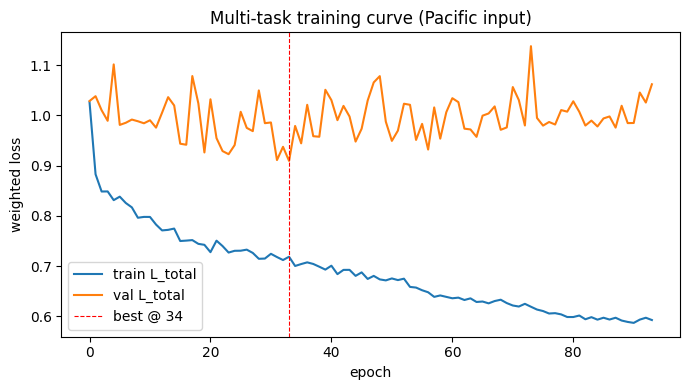

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(hist['train'], label='train L_total')
plt.plot(hist['val'],   label='val L_total')
plt.axvline(best_ep - 1, color='r', ls='--', lw=0.8, label=f'best @ {best_ep}')
plt.xlabel('epoch'); plt.ylabel('weighted loss'); plt.title('Multi-task training curve (Pacific input)')
plt.legend(); plt.tight_layout(); plt.show()


## 7 · Evaluation — ENSO head and impact head (per variable)


In [ ]:
from scipy.stats import pearsonr


@torch.no_grad()
def predict(xt):
    model.eval(); es, isb = [], []
    for i in range(0, xt.size(0), BATCH_SIZE):
        pe, pi = model(xt[i:i + BATCH_SIZE].to(device))
        es.append(pe.cpu()); isb.append(pi.cpu())
    return torch.cat(es).numpy(), torch.cat(isb).numpy()


def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))

pe_te, pi_te = predict(Xte)
print('== ENSO head (monthly ONI) ==')
print('test RMSE:', round(rmse(pe_te, Ete.numpy()), 4))
if len(Ete) > 1:
    print('test Pearson r:', round(pearsonr(pe_te, Ete.numpy())[0], 4))

print('\n== Impact head (monthly anomalies) ==')
pi_grid = pi_te.reshape(-1, 2, Hs, Ws)
it_grid = Ite.numpy().reshape(-1, 2, Hs, Ws)
for k, name in enumerate(['t2m', 'tp']):
    a, b = pi_grid[:, k].ravel(), it_grid[:, k].ravel()
    line = f'{name:4s}  test RMSE={rmse(a, b):.4f}'
    if a.size > 1:

        line += f'  spatial-r={pearsonr(a, b)[0]:.4f}'
    print(line)

== ENSO head (monthly ONI) ==
test RMSE: 0.3721
test Pearson r: 0.933

== Impact head (monthly anomalies) ==
t2m   test RMSE=1.0766  spatial-r=0.3004
tp    test RMSE=1.1079  spatial-r=0.1126


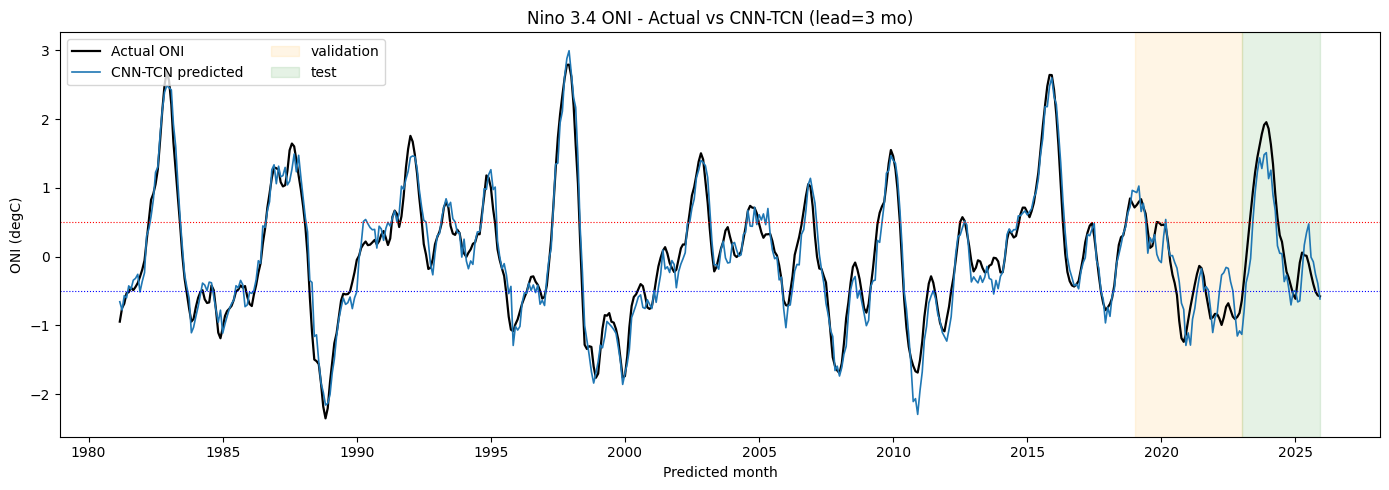

In [ ]:
# --- Full-timeline ONI: actual vs predicted (ENSO head) ---
sample_dt = pd.to_datetime(pd.DataFrame({'year': yrs, 'month': mos, 'day': 1}))
pe_full, _ = predict(torch.from_numpy(X_std).permute(0, 1, 4, 2, 3).contiguous())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_dt, y_enso, 'k-', lw=1.6, label='Actual ONI')
ax.plot(sample_dt, pe_full, color='C0', lw=1.2, label='CNN-TCN predicted')
ax.axhline(0.5,  color='r', ls=':', lw=0.8)
ax.axhline(-0.5, color='b', ls=':', lw=0.8)
ax.axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2022-12-31'), color='orange', alpha=0.10, label='validation')
ax.axvspan(pd.Timestamp('2023-01-01'), sample_dt.max(),            color='green',  alpha=0.10, label='test')
ax.set_title(f'Nino 3.4 ONI - Actual vs CNN-TCN (lead={LEAD} mo)')
ax.set_xlabel('Predicted month'); ax.set_ylabel('ONI (degC)')
ax.legend(loc='upper left', ncol=2); plt.tight_layout(); plt.show()

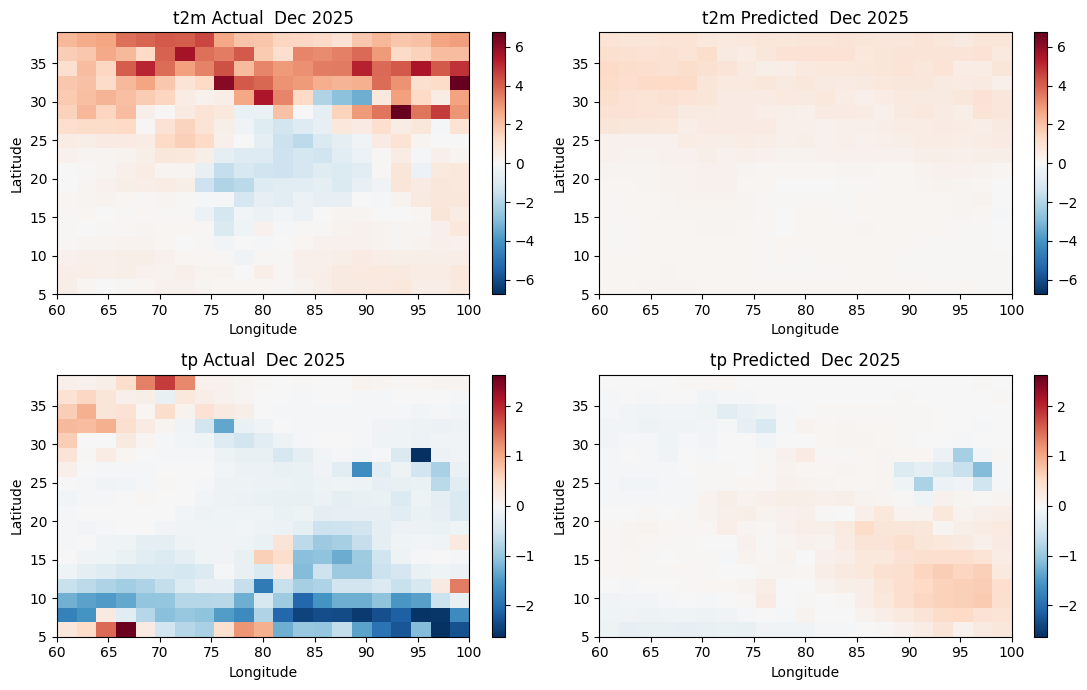

In [ ]:
# --- Predicted vs actual monthly SA anomaly maps for the last test month ---
yr = -1
year_label  = yrs[test_mask][yr]
month_label = mos[test_mask][yr]
month_name  = pd.Timestamp(year=2000, month=int(month_label), day=1).strftime('%b')
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
extent = [sa_lons.min(), sa_lons.max(), sa_lats.min(), sa_lats.max()]
for k, name in enumerate(['t2m', 'tp']):
    vmax = np.abs(it_grid[yr, k]).max()
    for j, (arr, title) in enumerate([(it_grid[yr, k], 'Actual'), (pi_grid[yr, k], 'Predicted')]):
        ax = axes[k, j]
        im = ax.imshow(arr, origin='lower', extent=extent, cmap='RdBu_r',
                       vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_title(f'{name} {title}  {month_name} {year_label}')
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


In [ ]:
torch.save({'state_dict': model.state_dict(),
            'mu': mu, 'sd': sd,
            'config': {'PAC_VARS': PAC_VARS, 'IMPACT_VARS': IMPACT_VARS,
                       'SEQ_LEN': SEQ_LEN, 'LEAD': LEAD, 'DROPOUT': DROPOUT,
                       'Hp': Hp, 'Wp': Wp, 'Cp': Cp, 'Hs': Hs, 'Ws': Ws,
                       'ALPHA': ALPHA, 'LAMBDA_CORR': LAMBDA_CORR,
                       'N_PCA_COMPONENTS': N_PCA_COMPONENTS}},
           'cnn_tcn_multitask_pacific_full.pt')
print('Saved -> cnn_tcn_multitask_pacific_full.pt  (weights + norm stats + config)')


Saved -> cnn_tcn_multitask_pacific_full.pt  (weights + norm stats + config)


## 8 · Multi-seed robustness check

A single run's test metrics are noisy (val=48, test=36 months), so a config change can look
like a win or a loss purely from seed variance. This retrains the model from scratch for
several seeds and reports **mean ± std** of each metric, which is the only fair way to compare
configs (PCA size, ALPHA, etc.) going forward.


In [ ]:
import os


def run_experiment(seed, epochs=EPOCHS, patience=PATIENCE):
    '''Retrain from scratch with a fresh seed; return test-set metrics for this run.'''
    torch.manual_seed(seed); np.random.seed(seed)
    tr_loader = DataLoader(TensorDataset(Xtr, Etr, Itr), batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(TensorDataset(Xva, Eva, Iva), batch_size=BATCH_SIZE)

    m = CNN_TCN_MultiTask(in_ch=Cp, pca_components=pca_components_t, pca_mean=pca_mean_t,
                          d=64, tcn_channels=(64, 32, 32), dropout=DROPOUT).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=20)

    def _epoch(loader, train):
        m.train() if train else m.eval()
        tot, n = 0.0, 0
        with torch.set_grad_enabled(train):
            for xb, eb, ib in loader:
                xb, eb, ib = xb.to(device), eb.to(device), ib.to(device)
                pe, pi = m(xb)
                l_impact = criterion(pi, ib) + LAMBDA_CORR * spatial_corr_loss(pi, ib)
                loss = ALPHA * criterion(pe, eb) + (1 - ALPHA) * l_impact
                if train:
                    opt.zero_grad(); loss.backward(); opt.step()
                tot += loss.item() * xb.size(0); n += xb.size(0)
        return tot / n

    ckpt = f'_tmp_seed{seed}.pt'
    best, wait = float('inf'), 0
    for ep in range(1, epochs + 1):
        tr = _epoch(tr_loader, True)
        va = _epoch(va_loader, False)
        sch.step(va)
        if va < best - 1e-6:
            best, wait = va, 0
            torch.save(m.state_dict(), ckpt)
        else:
            wait += 1
        if wait >= patience:
            break
    m.load_state_dict(torch.load(ckpt, map_location=device))
    os.remove(ckpt)

    @torch.no_grad()
    def _predict(xt):
        m.eval(); es, isb = [], []
        for i in range(0, xt.size(0), BATCH_SIZE):
            pe, pi = m(xt[i:i + BATCH_SIZE].to(device))
            es.append(pe.cpu()); isb.append(pi.cpu())
        return torch.cat(es).numpy(), torch.cat(isb).numpy()

    pe_s, pi_s = _predict(Xte)
    pig = pi_s.reshape(-1, 2, Hs, Ws)
    itg = Ite.numpy().reshape(-1, 2, Hs, Ws)
    out = {'seed': seed, 'best_val': best,
           'enso_rmse': rmse(pe_s, Ete.numpy()),
           'enso_r': pearsonr(pe_s, Ete.numpy())[0] if len(Ete) > 1 else np.nan}
    for k, name in enumerate(['t2m', 'tp']):
        a, b = pig[:, k].ravel(), itg[:, k].ravel()
        out[f'{name}_rmse'] = rmse(a, b)
        out[f'{name}_r'] = pearsonr(a, b)[0] if a.size > 1 else np.nan
    return out


SEEDS = [0, 1, 2, 3, 4]
records = []
for s in SEEDS:
    rec = run_experiment(s)
    print(f"seed {s}: ENSO RMSE={rec['enso_rmse']:.4f} r={rec['enso_r']:.4f}  "
          f"t2m r={rec['t2m_r']:.4f}  tp r={rec['tp_r']:.4f}")
    records.append(rec)

res_df = pd.DataFrame(records).set_index('seed')
print('\n== Per-seed results ==')
print(res_df.round(4))
print(f'\n== Multi-seed summary (mean +/- std over {len(SEEDS)} seeds) ==')
print(pd.concat({'mean': res_df.mean(), 'std': res_df.std()}, axis=1).round(4))


seed 0: ENSO RMSE=0.5708 r=0.9310  t2m r=0.2982  tp r=0.1024
seed 1: ENSO RMSE=0.5630 r=0.9037  t2m r=0.3007  tp r=0.1102
seed 2: ENSO RMSE=0.5794 r=0.8990  t2m r=0.3065  tp r=0.1067
seed 3: ENSO RMSE=0.4554 r=0.9341  t2m r=0.3070  tp r=0.1103
seed 4: ENSO RMSE=0.3782 r=0.9296  t2m r=0.3123  tp r=0.1142

== Per-seed results ==
      best_val  enso_rmse  enso_r  t2m_rmse   t2m_r  tp_rmse    tp_r
seed                                                                
0       0.9159     0.5708  0.9310    1.1088  0.2982   1.1085  0.1024
1       0.8944     0.5630  0.9037    1.0981  0.3007   1.1078  0.1102
2       0.9042     0.5794  0.8990    1.0897  0.3065   1.1125  0.1067
3       0.8964     0.4554  0.9341    1.0861  0.3070   1.1081  0.1103
4       0.9148     0.3782  0.9296    1.0685  0.3123   1.1077  0.1142

== Multi-seed summary (mean +/- std over 5 seeds) ==
             mean     std
best_val   0.9051  0.0100
enso_rmse  0.5094  0.0890
enso_r     0.9195  0.0167
t2m_rmse   1.0902  0.0150
t2m_

## 9 · Ensemble forecast for JJAS 2026 (dashboard-ready outputs)

Multi-seed **ensemble** forecast driven by the most recent observed Pacific window. Each of
the `SEEDS` members is trained once and cached to `forecast_outputs/members/`, so re-running
(or the future dashboard) reloads them instantly instead of retraining.

For every target month in Jun–Jul–Aug–Sep 2026 whose 12-month input window is fully
available (the window ends `LEAD=3` months before the target), all members are run and their
predictions combined into an **ensemble mean ± std** for the Niño 3.4 ONI and the South Asia
`t2m`/`tp` anomaly maps. Months without a complete input window are auto-skipped. All
artifacts are written to `forecast_outputs/` for the dashboard: `ensemble_oni_2026.csv`
(ONI table), `ensemble_maps_2026.npz` (mean/std grids), `forecast_meta.json` (labels/config),
and two PNG previews.

In [ ]:
import os, json, datetime

OUT_DIR    = 'forecast_outputs'
MEMBER_DIR = os.path.join(OUT_DIR, 'members')
os.makedirs(MEMBER_DIR, exist_ok=True)


def build_forecast_input(target_ts):
    '''Standardised (1,T,C,H,W) Pacific window for a target month, or None if incomplete.'''
    win_end = target_ts - pd.DateOffset(months=LEAD)
    win_ts  = [win_end - pd.DateOffset(months=SEQ_LEN - 1 - k) for k in range(SEQ_LEN)]
    if any(ts not in pac_idx for ts in win_ts):
        return None
    Xw = pac_grid[[pac_idx[ts] for ts in win_ts]]          # (T,Hp,Wp,Cp), NaNs already 0
    Xw = (Xw - mu) / sd                                     # train-only standardisation
    return torch.from_numpy(Xw.astype(np.float32)).permute(0, 3, 1, 2).unsqueeze(0).contiguous()


def train_member(seed, epochs=EPOCHS, patience=PATIENCE):
    '''Train one ensemble member from scratch and cache its best weights to disk.'''
    torch.manual_seed(seed); np.random.seed(seed)
    tr_loader = DataLoader(TensorDataset(Xtr, Etr, Itr), batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(TensorDataset(Xva, Eva, Iva), batch_size=BATCH_SIZE)
    m   = CNN_TCN_MultiTask(in_ch=Cp, pca_components=pca_components_t, pca_mean=pca_mean_t,
                            d=64, tcn_channels=(64, 32, 32), dropout=DROPOUT).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=20)
    path = os.path.join(MEMBER_DIR, f'member_seed{seed}.pt')
    best, wait = float('inf'), 0
    for ep in range(1, epochs + 1):
        m.train()
        for xb, eb, ib in tr_loader:
            xb, eb, ib = xb.to(device), eb.to(device), ib.to(device)
            pe, pi = m(xb)
            l_impact = criterion(pi, ib) + LAMBDA_CORR * spatial_corr_loss(pi, ib)
            loss = ALPHA * criterion(pe, eb) + (1 - ALPHA) * l_impact
            opt.zero_grad(); loss.backward(); opt.step()
        m.eval(); tot, n = 0.0, 0
        with torch.no_grad():
            for xb, eb, ib in va_loader:
                xb, eb, ib = xb.to(device), eb.to(device), ib.to(device)
                pe, pi = m(xb)
                l_impact = criterion(pi, ib) + LAMBDA_CORR * spatial_corr_loss(pi, ib)
                tot += (ALPHA * criterion(pe, eb) + (1 - ALPHA) * l_impact).item() * xb.size(0)
                n += xb.size(0)
        va = tot / n; sch.step(va)
        if va < best - 1e-6:
            best, wait = va, 0; torch.save(m.state_dict(), path)
        else:
            wait += 1
        if wait >= patience:
            break
    m.load_state_dict(torch.load(path, map_location=device))
    return m


def get_ensemble(seeds=SEEDS, retrain=False):
    '''Load cached members if present, else train + cache them.'''
    members = []
    for s in seeds:
        path = os.path.join(MEMBER_DIR, f'member_seed{s}.pt')
        if (not retrain) and os.path.exists(path):
            m = CNN_TCN_MultiTask(in_ch=Cp, pca_components=pca_components_t, pca_mean=pca_mean_t,
                                  d=64, tcn_channels=(64, 32, 32), dropout=DROPOUT).to(device)
            m.load_state_dict(torch.load(path, map_location=device))
            print(f'loaded   member seed {s}  <- {path}')
        else:
            print(f'training member seed {s} ...')
            m = train_member(s)
        members.append(m)
    return members


@torch.no_grad()
def forecast_month(members, target_ts):
    '''Return (oni_per_member[M], maps_per_member[M,2,Hs,Ws]) or None if window unavailable.'''
    xt = build_forecast_input(target_ts)
    if xt is None:
        return None
    onis, maps = [], []
    for m in members:
        m.eval()
        pe, pi = m(xt.to(device))
        onis.append(float(pe.cpu().numpy().ravel()[0]))
        maps.append(pi.cpu().numpy().reshape(2, Hs, Ws))
    return np.array(onis), np.stack(maps)


print('Ensemble helpers ready. Pacific data ends:', pac_times_pd.max().date())

In [ ]:
# --- Build (or load) the ensemble, then forecast JJAS 2026 ---
members = get_ensemble(SEEDS, retrain=False)

target_months = pd.to_datetime([f'2026-{m:02d}-01' for m in (6, 7, 8, 9)])
labels, reachable, skipped = [], [], []
oni_by_member, t2m_by_member, tp_by_member = [], [], []

for ts in target_months:
    res = forecast_month(members, ts)
    lab = ts.strftime('%b %Y')
    if res is None:
        skipped.append(lab)
        need = (ts - pd.DateOffset(months=LEAD)).strftime('%b %Y')
        print(f'{lab}: input window incomplete (needs Pacific through {need}) -> skipped')
        continue
    onis, maps = res                       # onis:(M,)  maps:(M,2,Hs,Ws)
    reachable.append(ts); labels.append(lab)
    oni_by_member.append(onis)
    t2m_by_member.append(maps[:, 0])       # (M,Hs,Ws)
    tp_by_member.append(maps[:, 1])
    print(f'{lab}: ensemble ONI = {onis.mean():+.3f} +/- {onis.std():.3f} degC')

assert reachable, 'No JJAS 2026 target month is reachable with the current data.'

oni_arr = np.array(oni_by_member)          # (n_month, M)
t2m_arr = np.stack(t2m_by_member)          # (n_month, M, Hs, Ws)
tp_arr  = np.stack(tp_by_member)
season  = 'JJAS' if len(labels) == 4 else ''.join(l[0] for l in labels)
seed_cols = [f'seed{s}' for s in SEEDS]

# --- ONI table: per-member + ensemble mean/std, plus a seasonal-mean row ---
oni_df = pd.DataFrame(oni_arr, index=labels, columns=seed_cols)
oni_df.loc[f'{season} mean'] = oni_arr.mean(axis=0)
oni_df['ens_mean'] = oni_df[seed_cols].mean(axis=1)
oni_df['ens_std']  = oni_df[seed_cols].std(axis=1)
oni_df.round(4).to_csv(os.path.join(OUT_DIR, 'ensemble_oni_2026.csv'))
print('\n== Ensemble ONI forecast ==')
print(oni_df.round(3))


def mean_std(arr):                         # arr:(n_month,M,Hs,Ws)
    per_month_mean = arr.mean(axis=1)                    # (n_month,Hs,Ws)
    per_month_std  = arr.std(axis=1)
    season_mean    = arr.mean(axis=(0, 1))[None]         # (1,Hs,Ws)
    season_std     = arr.mean(axis=0).std(axis=0)[None]  # member spread of seasonal mean
    return (np.concatenate([per_month_mean, season_mean]),
            np.concatenate([per_month_std,  season_std]))

t2m_mean, t2m_std = mean_std(t2m_arr)
tp_mean,  tp_std  = mean_std(tp_arr)
map_labels = labels + [f'{season} mean']

np.savez_compressed(os.path.join(OUT_DIR, 'ensemble_maps_2026.npz'),
                    months=np.array(map_labels), lats=sa_lats, lons=sa_lons,
                    t2m_mean=t2m_mean, t2m_std=t2m_std, tp_mean=tp_mean, tp_std=tp_std)

meta = {'generated': datetime.datetime.now().isoformat(timespec='seconds'),
        'target_months_requested': [t.strftime('%Y-%m') for t in target_months],
        'reachable': [t.strftime('%Y-%m') for t in reachable],
        'skipped': skipped, 'season_label': season,
        'n_members': len(SEEDS), 'seeds': list(SEEDS),
        'pac_data_max': str(pac_times_pd.max().date()),
        'lead_months': LEAD, 'seq_len': SEQ_LEN,
        'grid': {'Hs': int(Hs), 'Ws': int(Ws),
                 'lat_range': [float(sa_lats.min()), float(sa_lats.max())],
                 'lon_range': [float(sa_lons.min()), float(sa_lons.max())]},
        'files': {'oni_csv': 'ensemble_oni_2026.csv', 'maps_npz': 'ensemble_maps_2026.npz',
                  'oni_png': 'forecast_oni_2026.png', 'maps_png': 'forecast_maps_2026.png'}}
with open(os.path.join(OUT_DIR, 'forecast_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print('\nSaved ->', OUT_DIR, '| files:', sorted(os.listdir(OUT_DIR)))

In [ ]:
# --- Dashboard preview figures (also saved as PNG) ---
rows  = labels + [f'{season} mean']
means = oni_df.loc[rows, 'ens_mean'].values
stds  = oni_df.loc[rows, 'ens_std'].values

fig, ax = plt.subplots(figsize=(8, 4.5))
bar_colors = ['C3' if v >= 0 else 'C0' for v in means]
ax.bar(rows, means, yerr=stds, capsize=5, color=bar_colors, alpha=0.85, edgecolor='k')
ax.axhline(0.5,  color='r', ls=':', lw=0.8, label='El Nino thr (+0.5)')
ax.axhline(-0.5, color='b', ls=':', lw=0.8, label='La Nina thr (-0.5)')
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('Nino 3.4 ONI (degC)')
ax.set_title(f'Ensemble ONI forecast ({len(SEEDS)} members, lead={LEAD} mo)')
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'forecast_oni_2026.png'), dpi=130); plt.show()

extent = [sa_lons.min(), sa_lons.max(), sa_lats.min(), sa_lats.max()]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panels = [(t2m_mean[-1], 't2m mean',        'RdBu_r',  axes[0, 0]),
          (tp_mean[-1],  'tp mean',          'BrBG',    axes[0, 1]),
          (t2m_std[-1],  't2m spread (std)', 'viridis', axes[1, 0]),
          (tp_std[-1],   'tp spread (std)',  'viridis', axes[1, 1])]
for arr, title, cmap, ax in panels:
    if 'mean' in title:
        v = np.abs(arr).max(); kw = dict(cmap=cmap, vmin=-v, vmax=v)
    else:
        kw = dict(cmap=cmap, vmin=0)
    im = ax.imshow(arr, origin='lower', extent=extent, aspect='auto', **kw)
    ax.set_title(f'{title}  ({season} 2026)')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'forecast_maps_2026.png'), dpi=130); plt.show()
print('Preview figures saved to', OUT_DIR)